
# REINFORCE da zero: GridWorld con chiave, trappole e azioni stocastiche

Questo notebook implementa **REINFORCE** senza usare Gym o librerie di reinforcement learning.

L'ambiente contiene:

- una griglia con muri;
- una **chiave** che deve essere raccolta prima di poter terminare;
- un'uscita che dà una ricompensa positiva solo dopo aver preso la chiave;
- alcune trappole;
- azioni stocastiche: con una certa probabilità l'agente "scivola" lateralmente;
- stato aumentato con l'informazione `chiave raccolta / non raccolta`.

La policy è una distribuzione softmax tabellare:

$$
\pi_\theta(a\mid s)=
\frac{\exp(\theta_{s,a})}
{\sum_b \exp(\theta_{s,b})}
$$

Dopo ogni episodio, REINFORCE aggiorna i parametri usando:

$$
\theta \leftarrow \theta
+ \alpha \sum_t
\nabla_\theta \log \pi_\theta(a_t\mid s_t)
\left(G_t-b(s_t)\right),
$$

dove $G_t$ è il ritorno scontato e $b(s_t)$ è una baseline appresa, usata per ridurre la varianza.



In [16]:

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import deque

# Per rendere gli esperimenti riproducibili.
SEED = 7
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.figsize"] = (9, 5)

print("NumPy:", np.__version__)
print("Seed:", SEED)


NumPy: 2.5.1
Seed: 7



## 1. Ambiente

La posizione dell'agente non è sufficiente a descrivere completamente lo stato:
la stessa cella ha un significato diverso prima e dopo la raccolta della chiave.

Per questo lo stato è:

$$
s=(riga,\ colonna,\ possiede\_chiave).
$$

La griglia visibile ha quindi $(H\times W)$ celle, ma il numero massimo di stati è
$2HW$.

### Ricompense

- passo normale: `-0.02`;
- raccolta della chiave: `+0.40`;
- ingresso nell'uscita senza chiave: piccola penalità;
- trappola: `-1.0` e fine episodio;
- uscita con chiave: `+1.5` e fine episodio.

La penalità per passo incoraggia percorsi brevi. Le azioni stocastiche impediscono
all'agente di memorizzare semplicemente una sequenza perfettamente deterministica.


In [17]:

@dataclass
class StepResult:
    state: int
    reward: float
    terminated: bool
    info: dict


class KeyGridWorld:
    # Azioni: su, destra, giù, sinistra.
    ACTIONS = np.array([
        [-1,  0],
        [ 0,  1],
        [ 1,  0],
        [ 0, -1],
    ])
    ACTION_NAMES = ["su", "destra", "giu", "sinistra"]
    ACTION_SYMBOLS = np.array(["↑", "→", "↓", "←"])

    def __init__(self, slip_probability=0.12, max_steps=120, seed=0):
        self.height = 6
        self.width = 8

        self.start = (5, 0)
        self.key = (1, 2)
        self.goal = (0, 7)

        # Ostacoli che costringono l'agente a scegliere percorsi diversi.
        self.walls = {
            (0, 3), (1, 3), (2, 3),
            (3, 1), (3, 2), (3, 3),
            (4, 5), (4, 6),
        }

        # Entrare in una trappola termina l'episodio.
        self.traps = {(2, 6), (5, 5)}

        self.slip_probability = slip_probability
        self.max_steps = max_steps
        self.rng = np.random.default_rng(seed)

        self.n_actions = 4
        self.n_states = self.height * self.width * 2

        self.reset()

    def encode_state(self, position, has_key):
        r, c = position
        base = r * self.width + c
        return int(base + int(has_key) * self.height * self.width)

    def decode_state(self, state):
        has_key = state >= self.height * self.width
        base = state % (self.height * self.width)
        r, c = divmod(base, self.width)
        return (r, c), bool(has_key)

    def reset(self):
        self.position = self.start
        self.has_key = False
        self.steps = 0
        return self.encode_state(self.position, self.has_key)

    def _sample_executed_action(self, intended_action):
        # Con probabilità 1-slip l'azione viene eseguita correttamente.
        # Altrimenti si scivola a sinistra o a destra rispetto alla direzione scelta.
        if self.rng.random() >= self.slip_probability:
            return intended_action

        lateral_actions = [
            (intended_action - 1) % self.n_actions,
            (intended_action + 1) % self.n_actions,
        ]
        return int(self.rng.choice(lateral_actions))

    def step(self, intended_action):
        self.steps += 1
        executed_action = self._sample_executed_action(intended_action)

        delta = self.ACTIONS[executed_action]
        candidate = (self.position[0] + delta[0], self.position[1] + delta[1])

        # Se si esce dalla griglia o si colpisce un muro, si resta fermi.
        invalid = (
            candidate[0] < 0 or candidate[0] >= self.height
            or candidate[1] < 0 or candidate[1] >= self.width
            or candidate in self.walls
        )

        reward = -0.02
        if invalid:
            candidate = self.position
            reward -= 0.03

        self.position = candidate
        terminated = False
        event = "passo"

        if self.position in self.traps:
            reward = -1.0
            terminated = True
            event = "trappola"

        elif self.position == self.key and not self.has_key:
            self.has_key = True
            reward += 0.40
            event = "chiave raccolta"

        elif self.position == self.goal:
            if self.has_key:
                reward = 1.5
                terminated = True
                event = "uscita raggiunta"
            else:
                reward -= 0.15
                event = "uscita senza chiave"

        truncated = self.steps >= self.max_steps
        terminated = terminated or truncated
        if truncated and event == "passo":
            event = "limite passi"

        info = {
            "intended_action": intended_action,
            "executed_action": executed_action,
            "event": event,
            "has_key": self.has_key,
        }

        return StepResult(
            state=self.encode_state(self.position, self.has_key),
            reward=float(reward),
            terminated=terminated,
            info=info,
        )


env = KeyGridWorld(seed=SEED)

print("Numero massimo di stati:", env.n_states)
print("Numero di azioni:", env.n_actions)
print("Stato iniziale codificato:", env.reset())
print("Stato iniziale decodificato:", env.decode_state(env.reset()))


Numero massimo di stati: 96
Numero di azioni: 4
Stato iniziale codificato: 40
Stato iniziale decodificato: ((5, 0), False)


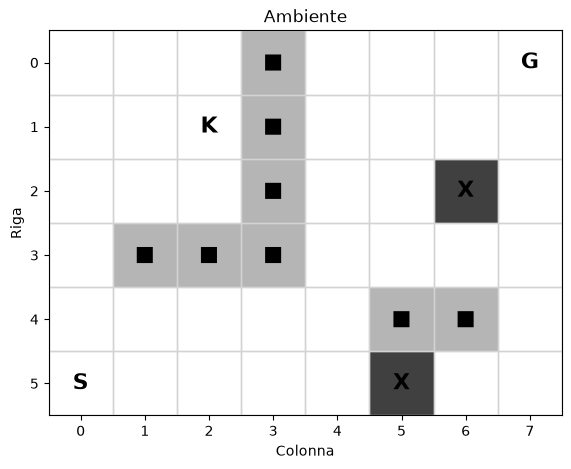

In [18]:

def draw_environment(env, ax=None, title="Ambiente"):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))

    grid = np.zeros((env.height, env.width))

    # Usiamo valori numerici solo per distinguere visivamente i tipi di cella.
    for r, c in env.walls:
        grid[r, c] = 1
    for r, c in env.traps:
        grid[r, c] = 2

    ax.imshow(grid, cmap="Greys", vmin=0, vmax=2.5)

    for r in range(env.height):
        for c in range(env.width):
            ax.add_patch(
                plt.Rectangle(
                    (c - 0.5, r - 0.5), 1, 1,
                    fill=False, edgecolor="lightgray", linewidth=1
                )
            )

    labels = {
        env.start: "S",
        env.key: "K",
        env.goal: "G",
    }
    for pos, text in labels.items():
        ax.text(pos[1], pos[0], text, ha="center", va="center",
                fontsize=16, fontweight="bold")

    for pos in env.traps:
        ax.text(pos[1], pos[0], "X", ha="center", va="center",
                fontsize=16, fontweight="bold")

    for pos in env.walls:
        ax.text(pos[1], pos[0], "■", ha="center", va="center", fontsize=15)

    ax.set_xticks(range(env.width))
    ax.set_yticks(range(env.height))
    ax.set_title(title)
    ax.set_xlabel("Colonna")
    ax.set_ylabel("Riga")
    return ax


draw_environment(env)
plt.show()



## 2. Policy softmax tabellare

Per ogni stato manteniamo quattro parametri, chiamati spesso **logit**:

```text
theta[state] = [logit_su, logit_destra, logit_giu, logit_sinistra]
```

La softmax converte questi numeri in probabilità.

La derivata necessaria a REINFORCE è particolarmente semplice:

$$
\nabla_{\theta_s}\log \pi(a\mid s)
=
\mathrm{onehot}(a)-\pi(\cdot\mid s).
$$

Questa espressione:

- aumenta il logit dell'azione scelta;
- riduce, in proporzione, i logit delle altre azioni;
- viene moltiplicata per il ritorno, o per il vantaggio rispetto alla baseline.


In [19]:

def softmax(logits):
    # Sottrarre il massimo rende il calcolo numericamente più stabile.
    shifted = logits - np.max(logits)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum()


def action_probabilities(theta, state):
    return softmax(theta[state])


def sample_action(theta, state, rng):
    probabilities = action_probabilities(theta, state)
    action = int(rng.choice(len(probabilities), p=probabilities))
    return action, probabilities


# Piccolo controllo: con logit tutti uguali, la policy è uniforme.
theta_demo = np.zeros((env.n_states, env.n_actions))
state_demo = env.reset()
print("Probabilità iniziali:", action_probabilities(theta_demo, state_demo))


Probabilità iniziali: [0.25 0.25 0.25 0.25]



## 3. Raccolta di un episodio

REINFORCE è un metodo **Monte Carlo**: prima raccoglie un episodio completo,
poi usa le ricompense future per aggiornare la policy.

Ogni transizione memorizza:

- stato $s_t$;
- azione intenzionale $a_t$;
- ricompensa $r_t$;
- probabilità della policy al momento della scelta;
- informazioni diagnostiche sull'azione realmente eseguita.


In [20]:

def generate_episode(env, theta, rng, deterministic=False):
    states = []
    actions = []
    rewards = []
    probabilities = []
    infos = []

    state = env.reset()
    done = False

    while not done:
        probs = action_probabilities(theta, state)

        if deterministic:
            action = int(np.argmax(probs))
        else:
            action = int(rng.choice(env.n_actions, p=probs))

        result = env.step(action)

        states.append(state)
        actions.append(action)
        rewards.append(result.reward)
        probabilities.append(probs.copy())
        infos.append(result.info)

        state = result.state
        done = result.terminated

    return {
        "states": np.array(states, dtype=int),
        "actions": np.array(actions, dtype=int),
        "rewards": np.array(rewards, dtype=float),
        "probabilities": np.array(probabilities, dtype=float),
        "infos": infos,
        "final_state": state,
    }


episode = generate_episode(env, theta_demo, rng)

print("Lunghezza episodio casuale:", len(episode["rewards"]))
print("Ritorno non scontato:", episode["rewards"].sum())
print("Prime 5 ricompense:", episode["rewards"][:5])
print("Ultimo evento:", episode["infos"][-1]["event"])


Lunghezza episodio casuale: 120
Ritorno non scontato: -3.66
Prime 5 ricompense: [-0.05 -0.05 -0.05 -0.02 -0.02]
Ultimo evento: limite passi



## 4. Ritorni scontati

Il ritorno dal tempo $t$ è:

$$
G_t=r_t+\gamma r_{t+1}+\gamma^2r_{t+2}+\dots
$$

Viene calcolato in modo efficiente scorrendo l'episodio al contrario.


In [21]:

def discounted_returns(rewards, gamma=0.99):
    returns = np.zeros_like(rewards, dtype=float)
    running_return = 0.0

    for t in reversed(range(len(rewards))):
        running_return = rewards[t] + gamma * running_return
        returns[t] = running_return

    return returns


example_rewards = np.array([-0.02, -0.02, 0.40, -0.02, 1.50])
example_returns = discounted_returns(example_rewards, gamma=0.95)

print("Ricompense:", example_rewards)
print("Ritorni scontati:", np.round(example_returns, 3))


Ricompense: [-0.02 -0.02  0.4  -0.02  1.5 ]
Ritorni scontati: [1.527 1.628 1.735 1.405 1.5  ]



## 5. Aggiornamento REINFORCE

La versione implementata sotto usa una baseline di stato $V(s)$, aggiornata con
una media mobile:

$$
V(s_t)\leftarrow V(s_t)+\beta\left(G_t-V(s_t)\right).
$$

Il segnale usato per la policy è quindi:

$$
A_t=G_t-V(s_t).
$$

`A_t` non è una stima bootstrapped dell'advantage: è semplicemente il ritorno
Monte Carlo centrato rispetto alla baseline.

Nel codice si normalizzano gli advantage all'interno dell'episodio. Non è
obbligatorio, ma spesso rende l'ottimizzazione più stabile.


In [22]:

def reinforce_update(
    theta,
    baseline,
    episode,
    policy_lr=0.025,
    baseline_lr=0.10,
    gamma=0.99,
    use_baseline=True,
    normalize_advantages=True,
):
    states = episode["states"]
    actions = episode["actions"]
    rewards = episode["rewards"]

    returns = discounted_returns(rewards, gamma=gamma)

    if use_baseline:
        old_baseline = baseline[states].copy()
        advantages = returns - old_baseline

        # La baseline viene aggiornata verso i ritorni osservati.
        for state, target in zip(states, returns):
            baseline[state] += baseline_lr * (target - baseline[state])
    else:
        advantages = returns.copy()

    if normalize_advantages and len(advantages) > 1:
        advantages = (
            advantages - advantages.mean()
        ) / (advantages.std() + 1e-8)

    # Aggiornamento della policy.
    for state, action, advantage in zip(states, actions, advantages):
        probs = action_probabilities(theta, state)

        grad_log_policy = -probs
        grad_log_policy[action] += 1.0

        theta[state] += policy_lr * advantage * grad_log_policy

    diagnostics = {
        "returns": returns,
        "advantages": advantages,
    }
    return diagnostics



## 6. Addestramento

Durante l'addestramento salviamo:

- ritorno totale dell'episodio;
- lunghezza;
- successo o fallimento;
- raccolta della chiave;
- entropia media della policy.

L'entropia misura quanto la policy è casuale:

\[
H(\pi)=-\sum_a \pi(a\mid s)\log\pi(a\mid s).
\]

All'inizio dovrebbe essere vicina a \(\log 4\), perché le quattro azioni sono quasi
equiprobabili. In seguito tende a diminuire negli stati visitati frequentemente.


In [23]:

def policy_entropy(theta, states):
    entropies = []
    for state in states:
        probs = action_probabilities(theta, state)
        entropy = -np.sum(probs * np.log(probs + 1e-12))
        entropies.append(entropy)
    return float(np.mean(entropies))


def moving_average(values, window=100):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return np.arange(len(values)), values
    kernel = np.ones(window) / window
    smoothed = np.convolve(values, kernel, mode="valid")
    x = np.arange(window - 1, len(values))
    return x, smoothed


def train_reinforce(
    env,
    n_episodes=10000,
    gamma=0.99,
    policy_lr=0.025,
    baseline_lr=0.10,
    use_baseline=True,
    seed=0,
    print_every=500,
):
    local_rng = np.random.default_rng(seed)

    # Piccolo rumore iniziale: rompe eventuali simmetrie.
    theta = local_rng.normal(
        loc=0.0, scale=0.01, size=(env.n_states, env.n_actions)
    )
    baseline = np.zeros(env.n_states, dtype=float)

    history = {
        "return": [],
        "length": [],
        "success": [],
        "key_collected": [],
        "entropy": [],
    }

    for episode_idx in range(1, n_episodes + 1):
        episode = generate_episode(env, theta, local_rng, deterministic=False)

        reinforce_update(
            theta=theta,
            baseline=baseline,
            episode=episode,
            policy_lr=policy_lr,
            baseline_lr=baseline_lr,
            gamma=gamma,
            use_baseline=use_baseline,
            normalize_advantages=True,
        )

        final_event = episode["infos"][-1]["event"]
        success = final_event == "uscita raggiunta"
        key_collected = any(
            info["event"] == "chiave raccolta"
            for info in episode["infos"]
        )

        history["return"].append(float(episode["rewards"].sum()))
        history["length"].append(len(episode["rewards"]))
        history["success"].append(float(success))
        history["key_collected"].append(float(key_collected))
        history["entropy"].append(
            policy_entropy(theta, np.unique(episode["states"]))
        )

        if episode_idx % print_every == 0:
            recent = slice(max(0, episode_idx - print_every), episode_idx)
            avg_return = np.mean(history["return"][recent])
            success_rate = np.mean(history["success"][recent])
            avg_length = np.mean(history["length"][recent])
            key_rate = np.mean(history["key_collected"][recent])

            print(
                f"Episodio {episode_idx:4d} | "
                f"ritorno medio {avg_return:7.3f} | "
                f"successo {success_rate:6.1%} | "
                f"chiave {key_rate:6.1%} | "
                f"lunghezza {avg_length:6.1f}"
            )

    return theta, baseline, history


training_env = KeyGridWorld(
    slip_probability=0.12,
    max_steps=120,
    seed=SEED,
)

theta, baseline, history = train_reinforce(
    training_env,
    n_episodes=5000,
    gamma=0.99,
    policy_lr=0.025,
    baseline_lr=0.10,
    use_baseline=True,
    seed=SEED,
    print_every=500,
)


Episodio  500 | ritorno medio  -1.537 | successo   0.0% | chiave   7.0% | lunghezza   23.1
Episodio 1000 | ritorno medio  -1.159 | successo   0.0% | chiave   0.4% | lunghezza    7.8
Episodio 1500 | ritorno medio  -1.131 | successo   0.0% | chiave   0.2% | lunghezza    6.8
Episodio 2000 | ritorno medio  -1.132 | successo   0.0% | chiave   0.4% | lunghezza    6.8
Episodio 2500 | ritorno medio  -1.122 | successo   0.0% | chiave   0.2% | lunghezza    6.4
Episodio 3000 | ritorno medio  -1.120 | successo   0.0% | chiave   0.0% | lunghezza    6.3
Episodio 3500 | ritorno medio  -1.127 | successo   0.0% | chiave   0.4% | lunghezza    6.7
Episodio 4000 | ritorno medio  -1.119 | successo   0.0% | chiave   0.0% | lunghezza    6.3
Episodio 4500 | ritorno medio  -1.119 | successo   0.0% | chiave   0.2% | lunghezza    6.4
Episodio 5000 | ritorno medio  -1.116 | successo   0.0% | chiave   0.0% | lunghezza    6.2


## 7. Curve di apprendimento

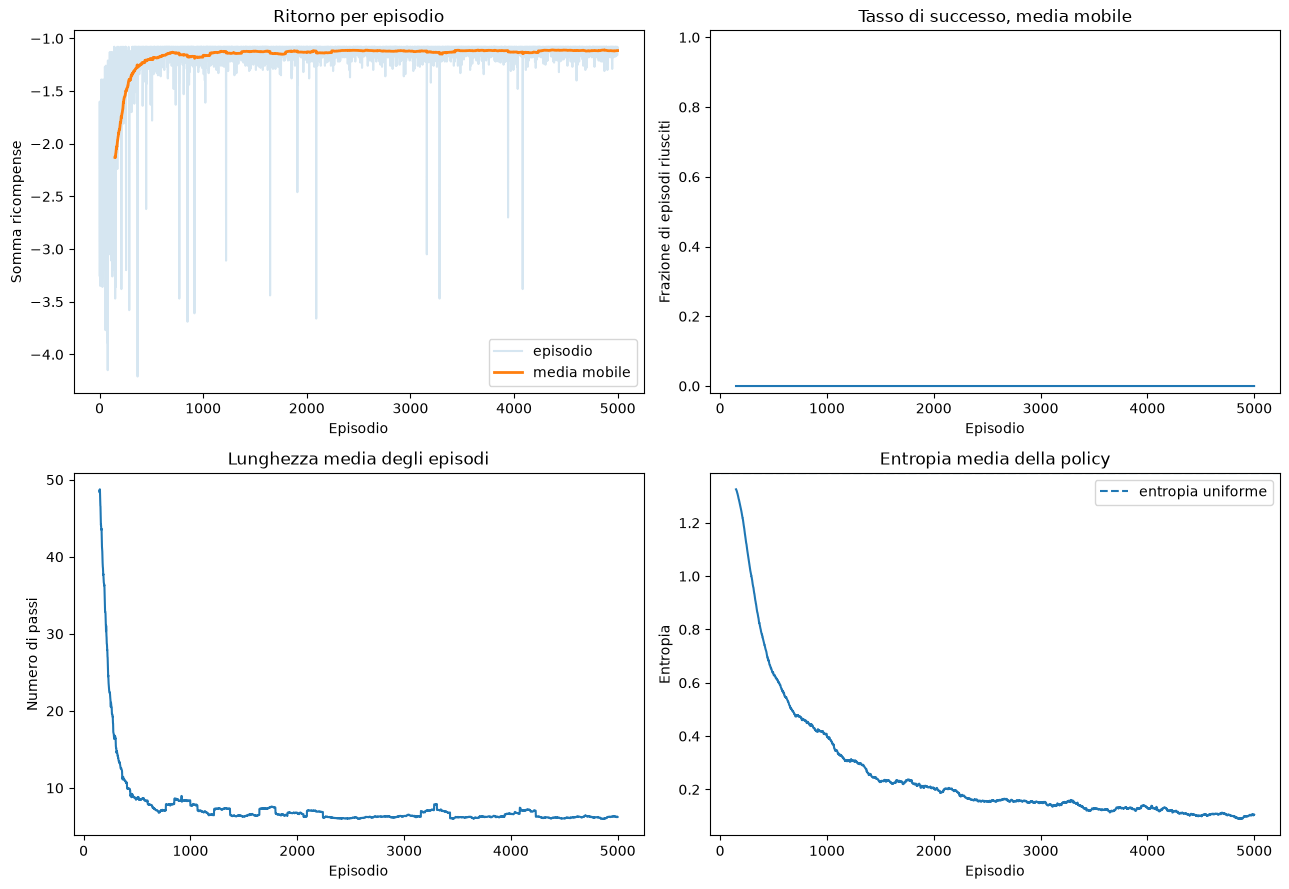

Successo negli ultimi 500 episodi: 0.0%
Ritorno medio negli ultimi 500 episodi: -1.116


In [24]:

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Ritorno episodico.
axes[0, 0].plot(history["return"], alpha=0.18, label="episodio")
x, y = moving_average(history["return"], window=150)
axes[0, 0].plot(x, y, linewidth=2, label="media mobile")
axes[0, 0].set_title("Ritorno per episodio")
axes[0, 0].set_xlabel("Episodio")
axes[0, 0].set_ylabel("Somma ricompense")
axes[0, 0].legend()

# Tasso di successo.
x, y = moving_average(history["success"], window=150)
axes[0, 1].plot(x, y)
axes[0, 1].set_ylim(-0.02, 1.02)
axes[0, 1].set_title("Tasso di successo, media mobile")
axes[0, 1].set_xlabel("Episodio")
axes[0, 1].set_ylabel("Frazione di episodi riusciti")

# Lunghezza.
x, y = moving_average(history["length"], window=150)
axes[1, 0].plot(x, y)
axes[1, 0].set_title("Lunghezza media degli episodi")
axes[1, 0].set_xlabel("Episodio")
axes[1, 0].set_ylabel("Numero di passi")

# Entropia.
x, y = moving_average(history["entropy"], window=150)
axes[1, 1].plot(x, y)
axes[1, 1].axhline(np.log(4), linestyle="--", label="entropia uniforme")
axes[1, 1].set_title("Entropia media della policy")
axes[1, 1].set_xlabel("Episodio")
axes[1, 1].set_ylabel("Entropia")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Successo negli ultimi 500 episodi:",
      f"{np.mean(history['success'][-500:]):.1%}")
print("Ritorno medio negli ultimi 500 episodi:",
      f"{np.mean(history['return'][-500:]):.3f}")



## 8. Visualizzazione della policy

Mostriamo due mappe:

1. policy quando la chiave non è ancora stata raccolta;
2. policy dopo la raccolta della chiave.

In ogni cella percorribile:

- la freccia grande è l'azione più probabile;
- il numero è la probabilità assegnata a quell'azione.

Una buona policy dovrebbe puntare verso la chiave nella prima mappa e verso
l'uscita nella seconda.


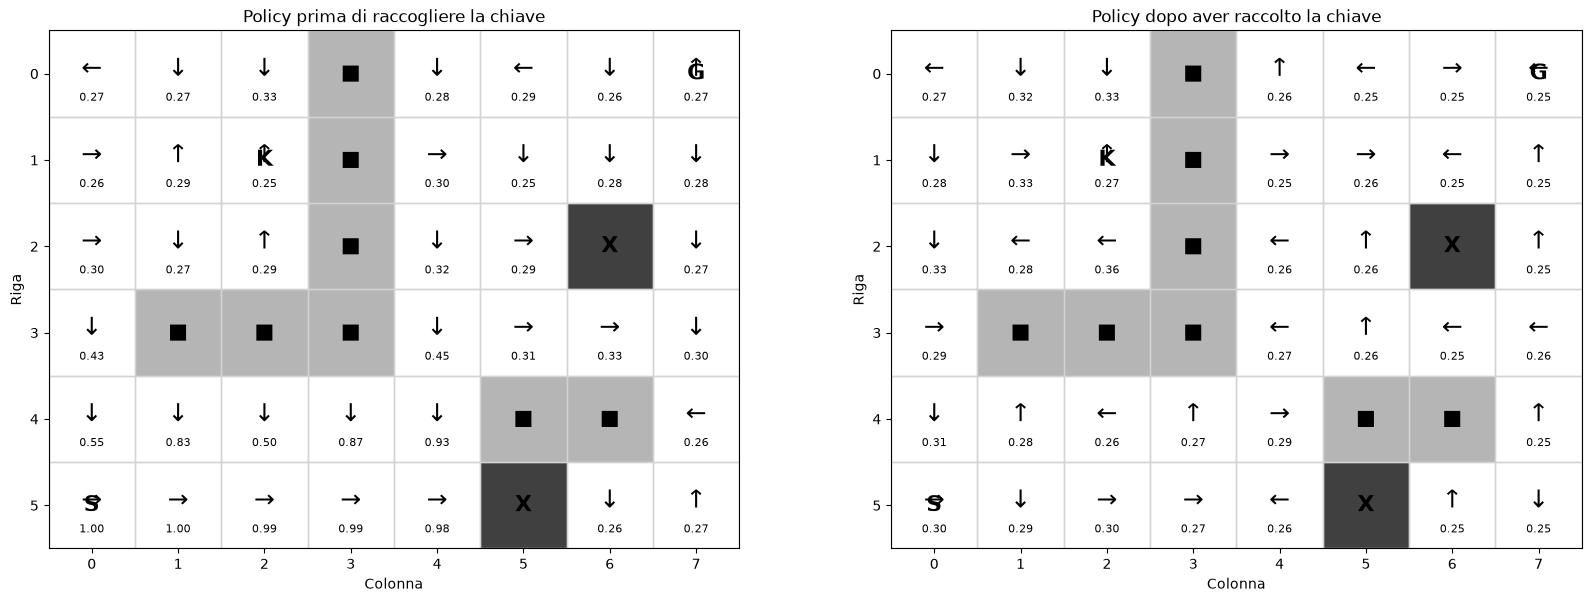

In [25]:

def draw_policy(env, theta, has_key, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    draw_environment(env, ax=ax, title=title or "Policy")

    for r in range(env.height):
        for c in range(env.width):
            pos = (r, c)

            if pos in env.walls or pos in env.traps:
                continue

            state = env.encode_state(pos, has_key)
            probs = action_probabilities(theta, state)
            best_action = int(np.argmax(probs))

            ax.text(
                c, r - 0.05,
                env.ACTION_SYMBOLS[best_action],
                ha="center", va="center",
                fontsize=18,
            )
            ax.text(
                c, r + 0.28,
                f"{probs[best_action]:.2f}",
                ha="center", va="center",
                fontsize=8,
            )

    return ax


fig, axes = plt.subplots(1, 2, figsize=(17, 6))

draw_policy(
    training_env, theta, has_key=False, ax=axes[0],
    title="Policy prima di raccogliere la chiave"
)
draw_policy(
    training_env, theta, has_key=True, ax=axes[1],
    title="Policy dopo aver raccolto la chiave"
)

plt.tight_layout()
plt.show()



## 9. Valutazione separata

Durante l'addestramento la policy deve rimanere stocastica, perché deve esplorare.
Per valutare ciò che ha imparato possiamo confrontare:

- policy stocastica: campiona dalle probabilità apprese;
- policy greedy: sceglie sempre l'azione più probabile.

Usiamo nuovi episodi e un nuovo generatore casuale, separato da quello usato
nell'addestramento.


In [26]:

def evaluate_policy(theta, n_episodes=500, deterministic=False, seed=123):
    eval_env = KeyGridWorld(
        slip_probability=0.12,
        max_steps=120,
        seed=seed,
    )
    eval_rng = np.random.default_rng(seed)

    returns = []
    lengths = []
    successes = []

    for _ in range(n_episodes):
        episode = generate_episode(
            eval_env, theta, eval_rng,
            deterministic=deterministic
        )
        returns.append(episode["rewards"].sum())
        lengths.append(len(episode["rewards"]))
        successes.append(
            episode["infos"][-1]["event"] == "uscita raggiunta"
        )

    return {
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "mean_length": float(np.mean(lengths)),
        "success_rate": float(np.mean(successes)),
    }


stochastic_metrics = evaluate_policy(
    theta, deterministic=False, seed=100
)
greedy_metrics = evaluate_policy(
    theta, deterministic=True, seed=200
)

print("Policy stocastica")
for key, value in stochastic_metrics.items():
    print(f"  {key:>14}: {value:.3f}")

print("\nPolicy greedy")
for key, value in greedy_metrics.items():
    print(f"  {key:>14}: {value:.3f}")


Policy stocastica
     mean_return: -1.121
      std_return: 0.119
     mean_length: 6.388
    success_rate: 0.000

Policy greedy
     mean_return: -1.113
      std_return: 0.041
     mean_length: 6.096
    success_rate: 0.000


## 10. Una traiettoria completa, passo per passo

In [27]:

rollout_env = KeyGridWorld(
    slip_probability=0.12,
    max_steps=120,
    seed=321,
)
rollout_rng = np.random.default_rng(321)

rollout = generate_episode(
    rollout_env, theta, rollout_rng,
    deterministic=True,
)

positions = []
has_key_flags = []

for state in rollout["states"]:
    position, has_key = rollout_env.decode_state(state)
    positions.append(position)
    has_key_flags.append(has_key)

final_position, final_has_key = rollout_env.decode_state(
    rollout["final_state"]
)
positions.append(final_position)
has_key_flags.append(final_has_key)

print("Numero di passi:", len(rollout["rewards"]))
print("Ritorno:", round(rollout["rewards"].sum(), 3))
print("Evento finale:", rollout["infos"][-1]["event"])
print()

max_rows_to_print = 35
for t, (state, action, reward, info) in enumerate(zip(
    rollout["states"],
    rollout["actions"],
    rollout["rewards"],
    rollout["infos"],
)):
    position, has_key = rollout_env.decode_state(state)
    intended = rollout_env.ACTION_NAMES[action]
    executed = rollout_env.ACTION_NAMES[info["executed_action"]]

    print(
        f"t={t:02d} | pos={position} | chiave={has_key!s:5s} | "
        f"azione={intended:7s} | eseguita={executed:7s} | "
        f"r={reward:+.2f} | {info['event']}"
    )

    if t + 1 >= max_rows_to_print and len(rollout["rewards"]) > max_rows_to_print:
        print("... output abbreviato ...")
        break


Numero di passi: 5
Ritorno: -1.08
Evento finale: trappola

t=00 | pos=(np.int64(5), np.int64(0)) | chiave=False | azione=destra  | eseguita=destra  | r=-0.02 | passo
t=01 | pos=(np.int64(5), np.int64(1)) | chiave=False | azione=destra  | eseguita=destra  | r=-0.02 | passo
t=02 | pos=(np.int64(5), np.int64(2)) | chiave=False | azione=destra  | eseguita=destra  | r=-0.02 | passo
t=03 | pos=(np.int64(5), np.int64(3)) | chiave=False | azione=destra  | eseguita=destra  | r=-0.02 | passo
t=04 | pos=(np.int64(5), np.int64(4)) | chiave=False | azione=destra  | eseguita=destra  | r=-1.00 | trappola


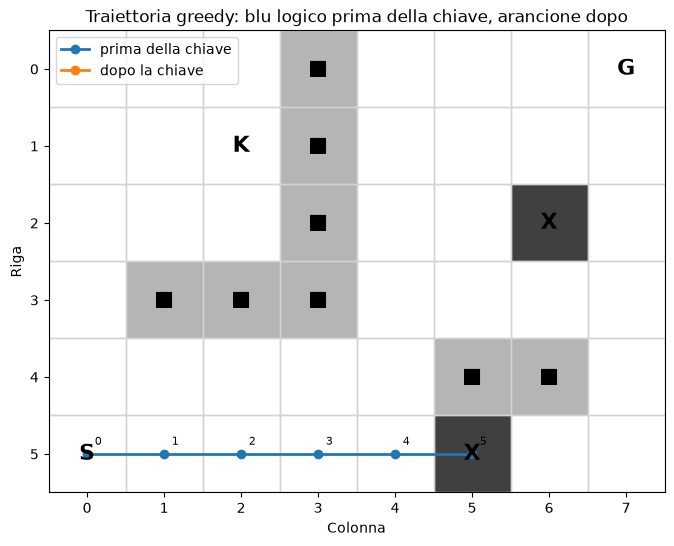

In [28]:

fig, ax = plt.subplots(figsize=(10, 6))
draw_environment(
    rollout_env, ax=ax,
    title="Traiettoria greedy: blu logico prima della chiave, arancione dopo"
)

# Disegniamo separatamente i segmenti prima e dopo la chiave.
before_x, before_y = [], []
after_x, after_y = [], []

key_seen = False
for pos, has_key in zip(positions, has_key_flags):
    x, y = pos[1], pos[0]
    if has_key:
        key_seen = True
    if key_seen:
        after_x.append(x)
        after_y.append(y)
    else:
        before_x.append(x)
        before_y.append(y)

ax.plot(before_x, before_y, marker="o", linewidth=2, label="prima della chiave")

# Ripetiamo il punto di passaggio per collegare visivamente i due tratti.
if before_x and after_x:
    after_x.insert(0, before_x[-1])
    after_y.insert(0, before_y[-1])

ax.plot(after_x, after_y, marker="o", linewidth=2, label="dopo la chiave")

for t, pos in enumerate(positions):
    ax.text(pos[1] + 0.10, pos[0] - 0.12, str(t), fontsize=8)

ax.legend()
plt.show()



## 11. Ispezione di un singolo aggiornamento

Questa sezione mostra numericamente cosa succede in uno stato scelto.

Per un'azione campionata \(a\), il gradiente:

\[
\mathrm{onehot}(a)-\pi(\cdot\mid s)
\]

ha una componente positiva per l'azione scelta e componenti negative per le altre.
Se l'advantage è positivo, l'azione scelta diventa più probabile. Se è negativo,
accade il contrario.


In [29]:

inspect_env = KeyGridWorld(seed=999)
inspect_rng = np.random.default_rng(999)

state = inspect_env.reset()
probs_before = action_probabilities(theta, state)
action = int(inspect_rng.choice(inspect_env.n_actions, p=probs_before))

grad_log_policy = -probs_before.copy()
grad_log_policy[action] += 1.0

hypothetical_advantage = 1.25
hypothetical_lr = 0.05
hypothetical_logits = (
    theta[state]
    + hypothetical_lr * hypothetical_advantage * grad_log_policy
)
probs_after = softmax(hypothetical_logits)

print("Stato:", inspect_env.decode_state(state))
print("Azione campionata:", inspect_env.ACTION_NAMES[action])
print("Probabilità prima:", probs_before)
print("Gradiente log-policy:", grad_log_policy)
print("Advantage ipotetico:", hypothetical_advantage)
print("Probabilità dopo un aggiornamento ipotetico:", probs_after)
print(
    "Variazione probabilità azione scelta:",
    round(probs_after[action] - probs_before[action], 5)
)


Stato: ((5, 0), False)
Azione campionata: destra
Probabilità prima: [0.002 0.996 0.001 0.001]
Gradiente log-policy: [-0.002  0.004 -0.001 -0.001]
Advantage ipotetico: 1.25
Probabilità dopo un aggiornamento ipotetico: [0.002 0.996 0.001 0.001]
Variazione probabilità azione scelta: 0.0



## 12. Esperimento: baseline oppure no

La baseline non cambia, in teoria, il valore atteso del policy gradient, ma può
ridurne fortemente la varianza.

Il confronto seguente usa meno episodi per mantenere ragionevoli i tempi di
esecuzione. Le singole curve possono essere rumorose: per un confronto rigoroso
servirebbero più seed e intervalli di confidenza.


Episodio 2500 | ritorno medio  -1.248 | successo   0.0% | chiave   2.7% | lunghezza   11.9
Episodio 2500 | ritorno medio  -1.266 | successo   0.1% | chiave   3.2% | lunghezza   12.8


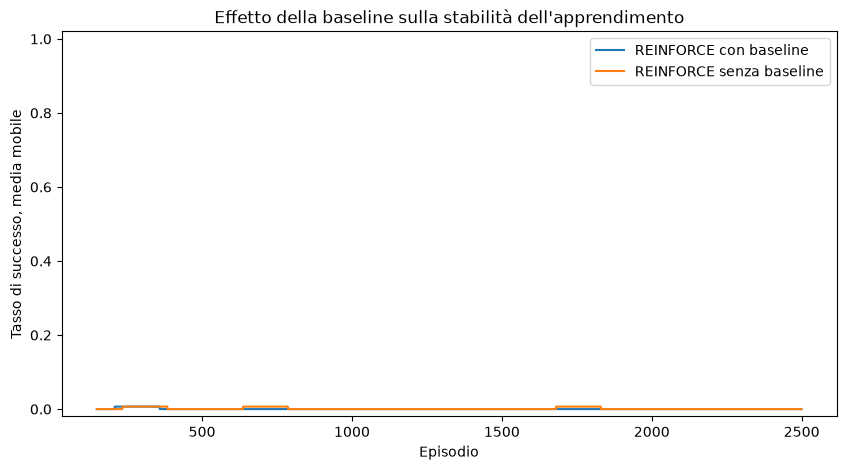

Successo finale con baseline: 0.0%
Successo finale senza baseline: 0.0%


In [30]:

comparison_episodes = 2500

env_with_baseline = KeyGridWorld(seed=41)
theta_b, baseline_b, history_b = train_reinforce(
    env_with_baseline,
    n_episodes=comparison_episodes,
    policy_lr=0.025,
    baseline_lr=0.10,
    use_baseline=True,
    seed=41,
    print_every=comparison_episodes,
)

env_without_baseline = KeyGridWorld(seed=41)
theta_nb, baseline_nb, history_nb = train_reinforce(
    env_without_baseline,
    n_episodes=comparison_episodes,
    policy_lr=0.025,
    baseline_lr=0.10,
    use_baseline=False,
    seed=41,
    print_every=comparison_episodes,
)

x_b, y_b = moving_average(history_b["success"], window=150)
x_nb, y_nb = moving_average(history_nb["success"], window=150)

plt.figure(figsize=(10, 5))
plt.plot(x_b, y_b, label="REINFORCE con baseline")
plt.plot(x_nb, y_nb, label="REINFORCE senza baseline")
plt.ylim(-0.02, 1.02)
plt.xlabel("Episodio")
plt.ylabel("Tasso di successo, media mobile")
plt.title("Effetto della baseline sulla stabilità dell'apprendimento")
plt.legend()
plt.show()

print(
    "Successo finale con baseline:",
    f"{np.mean(history_b['success'][-400:]):.1%}"
)
print(
    "Successo finale senza baseline:",
    f"{np.mean(history_nb['success'][-400:]):.1%}"
)



## 13. Cosa osservare

Durante l'esecuzione del notebook conviene controllare questi aspetti:

1. **Ritardo del credito.** La ricompensa dell'uscita influenza anche le azioni
   compiute molti passi prima.
2. **Esplorazione implicita.** La policy è stocastica, quindi REINFORCE esplora
   senza una regola epsilon-greedy separata.
3. **Alta varianza.** Le curve episodio per episodio sono rumorose.
4. **Baseline.** Sottrarre una stima del valore rende il segnale più centrato.
5. **Stato Markoviano.** Includere `has_key` è necessario: senza questa variabile,
   la stessa posizione richiederebbe comportamenti incompatibili.
6. **On-policy.** Gli episodi devono essere generati dalla policy corrente.
7. **Policy differenti nelle due modalità.** Prima della chiave l'agente dovrebbe
   dirigersi verso `K`; dopo la chiave dovrebbe dirigersi verso `G`.

## Possibili modifiche

- aumentare `slip_probability`;
- rimuovere la baseline;
- cambiare `gamma`;
- eliminare la normalizzazione degli advantage;
- aggiungere un bonus di entropia;
- confrontare più seed;
- sostituire la tabella con una rete neurale.

## Limite importante

REINFORCE puro usa episodi completi e ritorni Monte Carlo. È concettualmente
pulito, ma può essere inefficiente e molto variabile. Metodi actor-critic
introducono una stima del valore più strutturata e aggiornamenti più frequenti.
